# MSA 2026 Phase 2 - Part 1

In [14]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Find all variables and understand them

Features Dataset:  (8190, 12)
Sales Dataset:  (421570, 5)
Stores Dataset:  (45, 3)
First 10 instances:
Features Dataset:
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19        39.93       2.514        NaN        NaN   
3      1  2010-02-26        46.63       2.561        NaN        NaN   
4      1  2010-03-05        46.50       2.625        NaN        NaN   
5      1  2010-03-12        57.79       2.667        NaN        NaN   
6      1  2010-03-19        54.58       2.720        NaN        NaN   
7      1  2010-03-26        51.45       2.732        NaN        NaN   
8      1  2010-04-02        62.27       2.719        NaN        NaN   
9      1  2010-04-09        65.86       2.770        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN

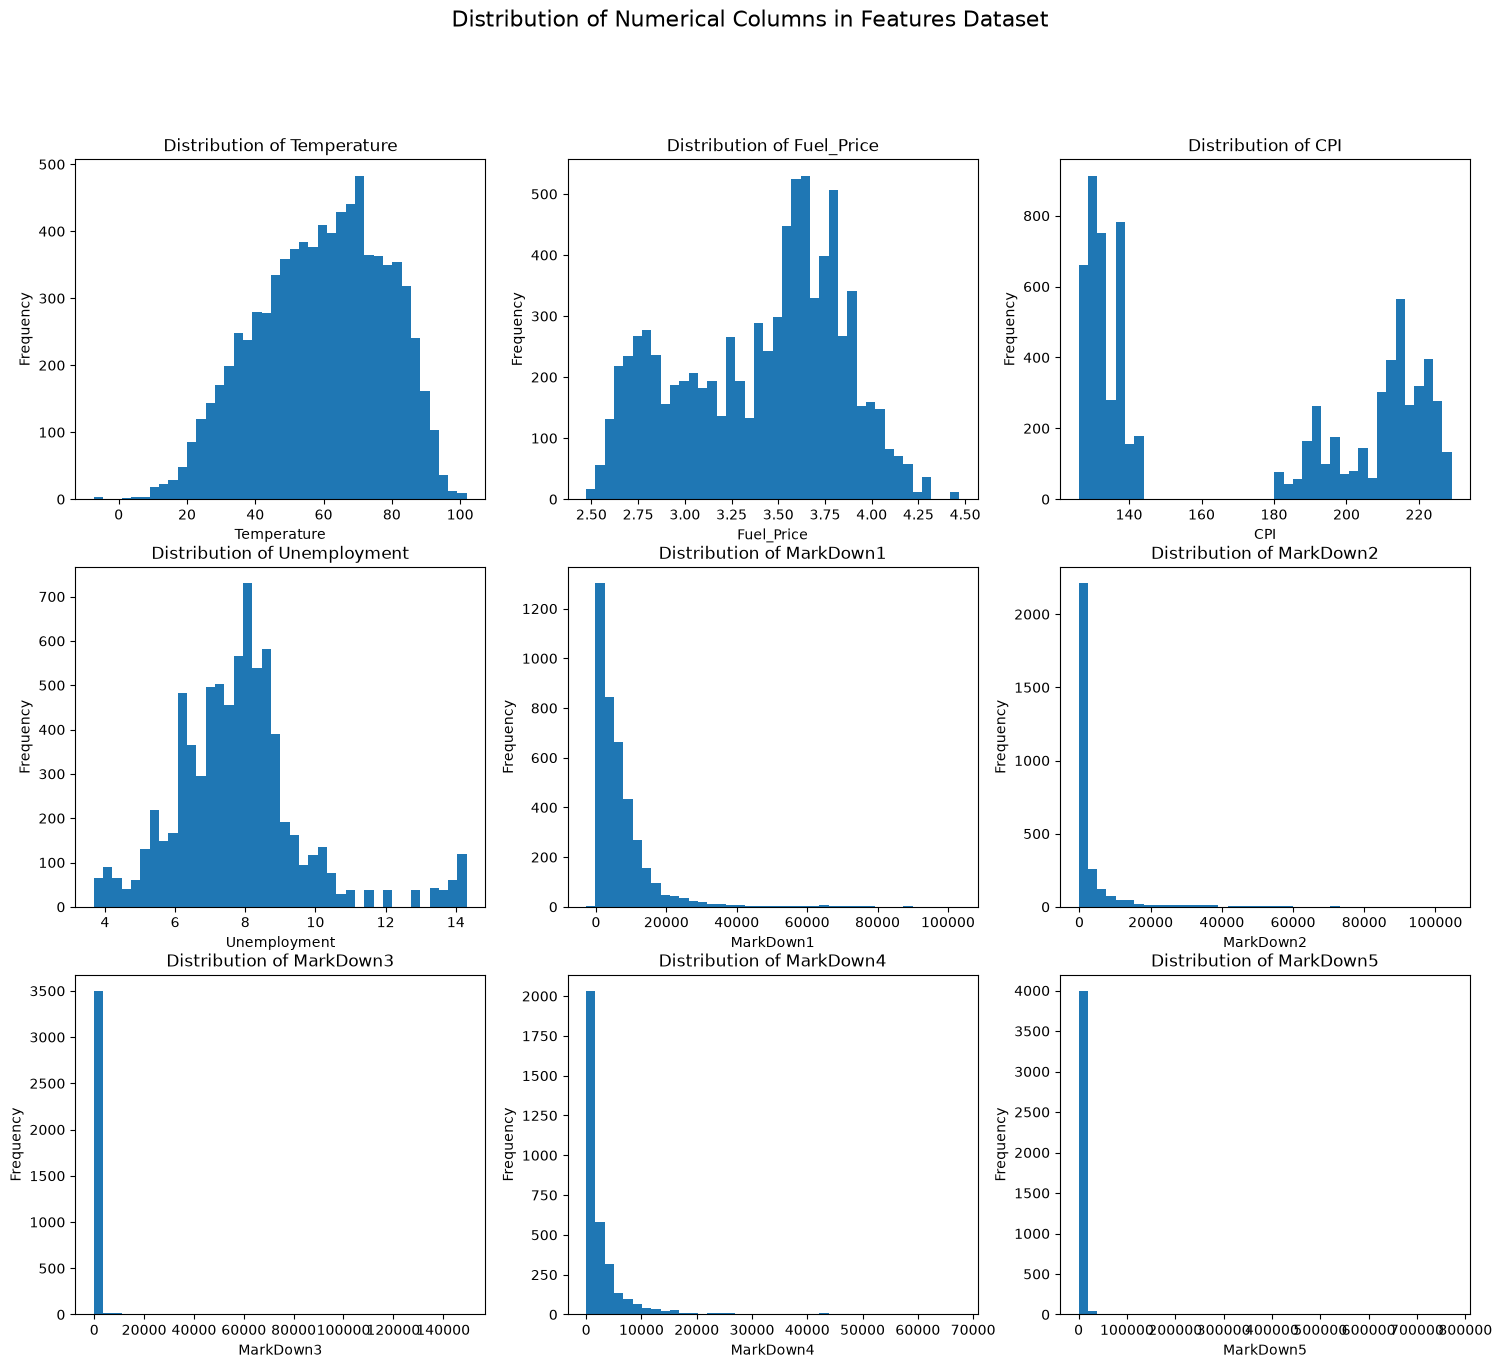

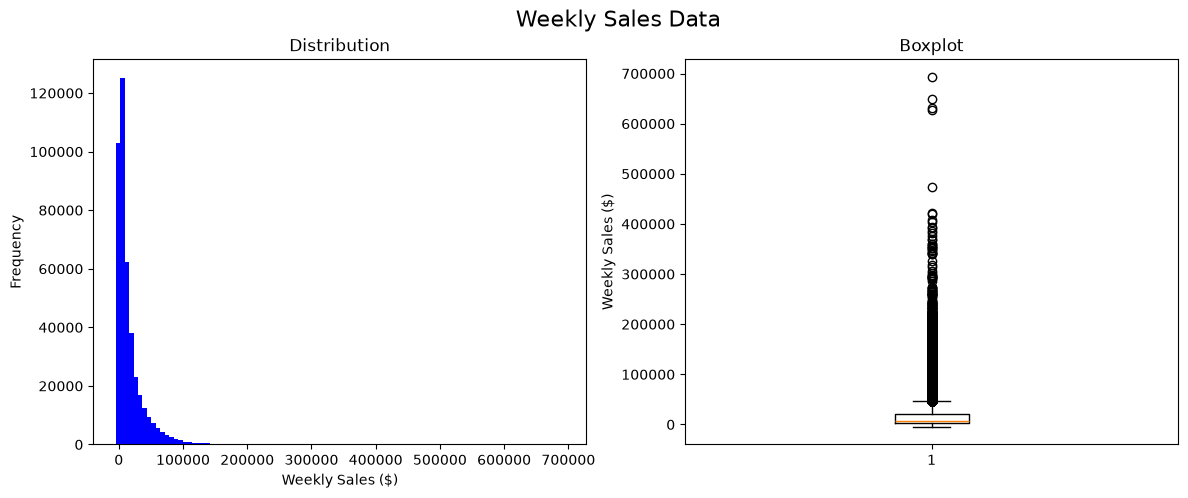

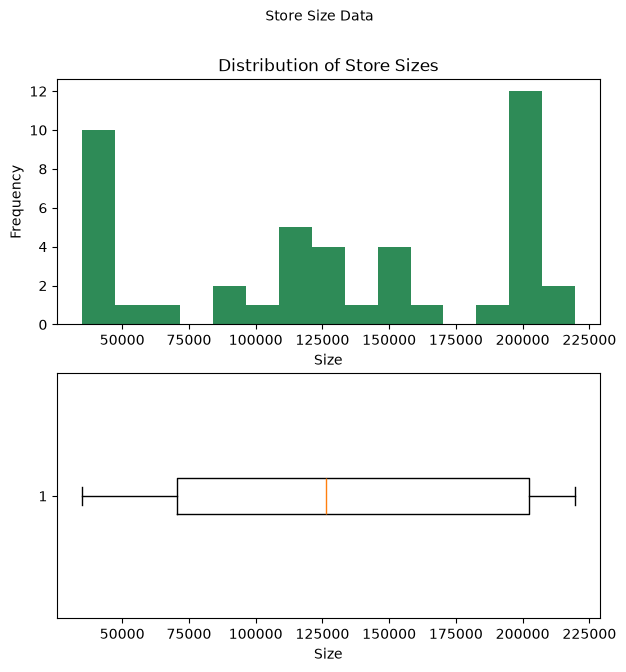

Type of columns:
features_df 
 Store             int64
Date                str
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object 

sales_df 
 Store             int64
Dept              int64
Date                str
Weekly_Sales    float64
IsHoliday          bool
dtype: object 

store_df 
 Store    int64
Type       str
Size     int64
dtype: object
features_df
        Date  Year  Week  Quarter
0 2010-02-05  2010     5        1
1 2010-02-12  2010     6        1
2 2010-02-19  2010     7        1
3 2010-02-26  2010     8        1
4 2010-03-05  2010     9        1
sales_df
        Date  Year  Week  Quarter
0 2010-02-05  2010     5        1
1 2010-02-12  2010     6        1
2 2010-02-19  2010     7        1
3 2010-02-26  2010     8        1
4 2010-03-05  2010     9        1
int64
int64
   Stor

In [15]:
### W store sales dataset
features_df = pd.read_csv("datasets/W store sales/features.csv", delimiter=",", header="infer")
sales_df = pd.read_csv("datasets/W store sales/sales.csv", delimiter=",", header="infer")
store_df = pd.read_csv("datasets/W store sales/stores.csv", delimiter=",", header="infer")

### Check number of rows and columns in each dataset
print("Features Dataset: ", features_df.shape)
print("Sales Dataset: ", sales_df.shape)
print("Stores Dataset: ", store_df.shape)


### Display the first ten instances.
print("First 10 instances:")
print("Features Dataset:")
print(features_df.head(10))
print("\nSales Dataset:")
print(sales_df.head(10))
print("\nStores Dataset:")
print(store_df.head(10))

### Key statistical measures
print("\nKey Statistical Measures:")
print("Features Dataset:")
print(features_df.describe())
print("\nSales Dataset:")
print(sales_df.describe())
print("\nStores Dataset:")
print(store_df.describe())


### Visualize all numerical columns 
## features_df
numerical_variables = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
fig, ax = plt.subplots(3, 3, figsize=(18, 15))
for i in range(len(numerical_variables)):
    row = i // 3
    col = i % 3
    axes = ax[row, col]
    axes.hist(features_df[numerical_variables[i]], bins=40)
    axes.set_title(f"Distribution of {numerical_variables[i]}")
    axes.set_xlabel(numerical_variables[i])
    axes.set_ylabel("Frequency")
plt.suptitle("Distribution of Numerical Columns in Features Dataset", fontsize=16)
plt.show()

## sales_df
# Weekly_Sales:
sales = sales_df["Weekly_Sales"]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of weekly sales on the first axis
ax[0].hist(sales, bins=100, color="blue")
ax[0].set_title("Distribution")
ax[0].set_xlabel("Weekly Sales ($)")
ax[0].set_ylabel("Frequency")

# Boxplot of weekly sales on the second axis
ax[1].boxplot(sales)
ax[1].set_title('Boxplot')
ax[1].set_ylabel("Weekly Sales ($)")

plt.suptitle('Weekly Sales Data', fontsize=16)
plt.show()


## store_df
fig, ax = plt.subplots(2, 1, figsize=(7, 7))

# Histogram of store sizes on the first axis
ax[0].hist(store_df["Size"], bins=15, color="seagreen")
ax[0].set_title("Distribution of Store Sizes")
ax[0].set_xlabel("Size")
ax[0].set_ylabel("Frequency")

# Boxplot of store sizes on the first axis
ax[1].boxplot(store_df["Size"], orientation="horizontal")
ax[1].set_xlabel("Size")
plt.suptitle('Store Size Data', fontsize=10)
plt.show()

### Convert types of variables into numerical values
## Check type of each variable and null values in each dataset
print("Type of columns:")
print("features_df \n", features_df.dtypes, "\n")
print("sales_df \n", sales_df.dtypes, "\n")
print("store_df \n", store_df.dtypes)

## Convert the Date column to datetime type
dataframes = [features_df, sales_df]
for df in dataframes:
    df["Date"] = pd.to_datetime(df["Date"]) 
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
    df["Quarter"] = df["Date"].dt.quarter
    print("features_df" if df is features_df else "sales_df")
    print(df[["Date", "Year", "Week", "Quarter"]].head())

## Convert the IsHoliday column to integer type
for df in dataframes:
    df["IsHoliday"] = df["IsHoliday"].astype(int)
    print(df["IsHoliday"].dtype)


## Convert types of store into numerical values by one-hot encoding
store_df_encoded = pd.get_dummies(store_df, columns=["Type"], prefix="Type").astype(int)
print(store_df_encoded.head())

## Check types of variables for all three datasets after conversion:
print("Type of columns (after conversion):")
print("features_df \n", features_df.dtypes, "\n")
print("sales_df \n", sales_df.dtypes, "\n")
print("store_df_encoded \n", store_df_encoded.dtypes)


## 2. Clean data

Missing values in features_df:
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
Year               0
Month              0
Week               0
Quarter            0
dtype: int64

Missing values in sales_df:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Year            0
Month           0
Week            0
Quarter         0
dtype: int64

Missing values in store_df_encoded:
Store     0
Size      0
Type_A    0
Type_B    0
Type_C    0
dtype: int64

Missing values in features_df after imputating markdown columns:
      Store       Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
169       1 2013-05-03        66.66       3.386    2298.63       2.00   
170       1 2013-05-10        63.90       3.392    4624.61      83.88   
171       1 2013-05-1

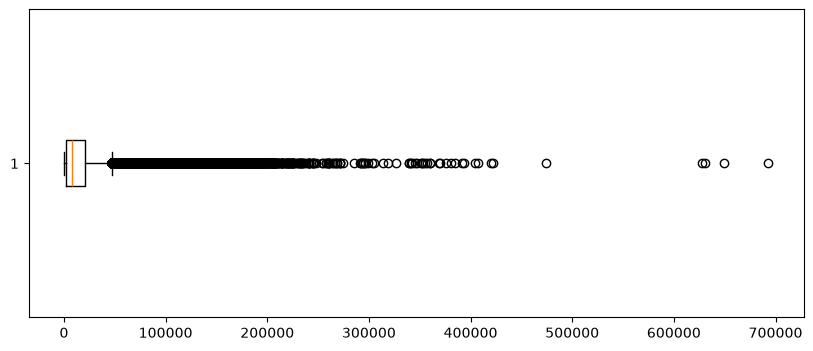

Q1: 2117.56, Q3: 20268.38, IQR: 18150.82
New Q3: 65645.43000000001
Percentage of outliers: 4.2645%


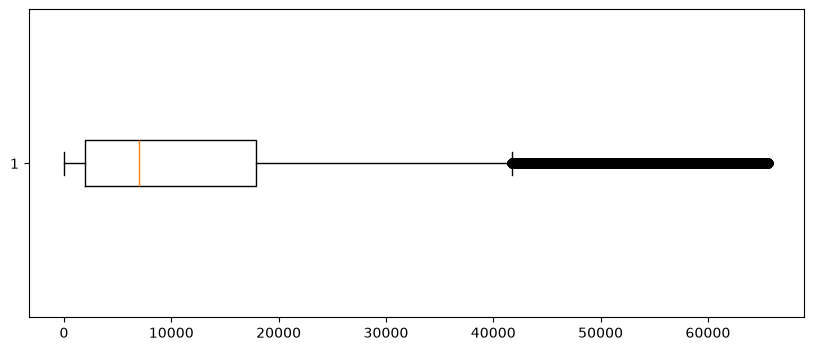

   Store  Dept       Date  Weekly_Sales  IsHoliday  Year  Month  Week  Quarter
0      1     1 2010-02-05      24924.50          0  2010      2     5        1
1      1     1 2010-02-12      46039.49          1  2010      2     6        1
2      1     1 2010-02-19      41595.55          0  2010      2     7        1
3      1     1 2010-02-26      19403.54          0  2010      2     8        1
4      1     1 2010-03-05      21827.90          0  2010      3     9        1
Number of holiday instances: 28170
Number of non-holiday instances: 374192
Number of undersampled-non-holiday-holiday instances: 28170
IsHoliday
1    28170
0    28170
Name: count, dtype: int64
Index(['Store', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday', 'Year', 'Month', 'Week', 'Quarter'],
      dtype='str')
Index(['Store', 'Dept', 'Weekly_Sales', 'IsHoliday', 'Year', 'Month', 'Week',
       'Quarter'],
      dtype='str')


In [16]:
###Missing values by dropping instances with missing values or entire attributes containing missing values, imputing the missing values for a particular attribute.
## Check for missing values in each dataset:
# features_df
print("Missing values in features_df:")
print(features_df.isnull().sum())

# sales_df
print("\nMissing values in sales_df:")
print(sales_df.isnull().sum())

# store_df_encoded
print("\nMissing values in store_df_encoded:")
print(store_df_encoded.isnull().sum())

## fill missing values in markdown columns in features_df with 0
markdown_columns = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
features_df[markdown_columns] = features_df[markdown_columns].fillna(0) 
print("\nMissing values in features_df after imputating markdown columns:")
print(features_df[features_df.isnull().any(axis=1)])

## CPI & Unemployment:
# fill missing values in CPI and Unemployment columns with the medians
cpi_unemp_variables = ["CPI", "Unemployment"]
for var in cpi_unemp_variables:
    features_df[var] = features_df[var].fillna(features_df[var].median())
print("\nMissing values in features_df after imputating CPI and Unemployment:")
print(features_df[features_df.isnull().any(axis=1)])


### Outliers by removing them and standardising/normalising them so that all our feature ranges are similar to each other, which helps our model learn better.
## Negative sales:
# Check for negative sales in sales_df:
negative_sales = sales_df[sales_df["Weekly_Sales"] < 0]
print(negative_sales)

# Percentage of negative sales to total sales:
percentage_negative_sales = (len(negative_sales) / len(sales_df)) * 100
print(f"Percentage of negative sales: {percentage_negative_sales:.4f}%")

# Filter out negative sales from sales_df
filtered_sales_df = sales_df[sales_df["Weekly_Sales"] >= 0]
print(f"sales_df: {sales_df.shape}")
print(f"filtered_sales_df: {filtered_sales_df.shape}")
print(filtered_sales_df)
print(filtered_sales_df["Weekly_Sales"].describe())

# Visualise the distribution of Weekly_Sales 
plt.figure(figsize=(10,4))
plt.boxplot(filtered_sales_df["Weekly_Sales"], orientation="horizontal")
plt.show()

## Outliers:
# Find IQR and outliers in filtered_sales_df
Q1 = filtered_sales_df["Weekly_Sales"].quantile(0.25)
Q3 = filtered_sales_df["Weekly_Sales"].quantile(0.75) 
IQR = Q3 - Q1
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")

# Adjust Q3 to include peak sales seasons (Holidays)
new_Q3 = Q3 + 2.5 * IQR 
print(f"New Q3: {new_Q3}")
outliers = filtered_sales_df[filtered_sales_df["Weekly_Sales"] > new_Q3]
removed_outliers_filtered_sales_df = filtered_sales_df[filtered_sales_df["Weekly_Sales"] <= new_Q3]

# Percentage of outliers to total sales:
percentage_outliers = (len(outliers) / len(filtered_sales_df)) * 100
print(f"Percentage of outliers: {percentage_outliers:.4f}%")

# Visualise the distribution of Weekly_Sales after removing outliers 
plt.figure(figsize=(10,4))
plt.boxplot(removed_outliers_filtered_sales_df["Weekly_Sales"], orientation="horizontal")
plt.show()


## Standardisation:
scaler = StandardScaler()

# Copy of features_df
standardised_features_df = features_df.copy()

# Standardise the numerical variables
standardised_features_df[numerical_variables] = scaler.fit_transform(standardised_features_df[numerical_variables])

# Display the mean and standard deviation
standardised_features_df[numerical_variables].describe().loc[["mean", "std"]]


### Imbalanced data by undersampling/oversampling for a particular label.
## IsHoliday:
print(removed_outliers_filtered_sales_df.head())

# Display number of rows for each class in the IsHoliday column
filtered_holiday = removed_outliers_filtered_sales_df[removed_outliers_filtered_sales_df["IsHoliday"] == 1]
filtered_non_holiday = removed_outliers_filtered_sales_df[removed_outliers_filtered_sales_df["IsHoliday"] == 0]
print(f"Number of holiday instances: {len(filtered_holiday)}")
print(f"Number of non-holiday instances: {len(filtered_non_holiday)}")

# Balance number of instances in each class by undersampling the majority class (non-holiday)
undersampled_filtered_non_holiday = filtered_non_holiday.sample(n=len(filtered_holiday), random_state=0)
print(f"Number of undersampled-non-holiday-holiday instances: {len(undersampled_filtered_non_holiday)}")

# Concatenate holiday and undersampled non-holiday:
balanced_holiday_data = pd.concat([filtered_holiday, undersampled_filtered_non_holiday])
print(balanced_holiday_data["IsHoliday"].value_counts())

### Feature selection by selecting the most important features to feed into our model while ignoring any insignificant features.
## Drop insignificant columns:
final_features_df = standardised_features_df.drop(columns = ["Date"])
final_sales_df = balanced_holiday_data.drop(columns = ["Date"])
print(final_features_df.columns)
print(final_sales_df.columns)




## 3. Visualise data

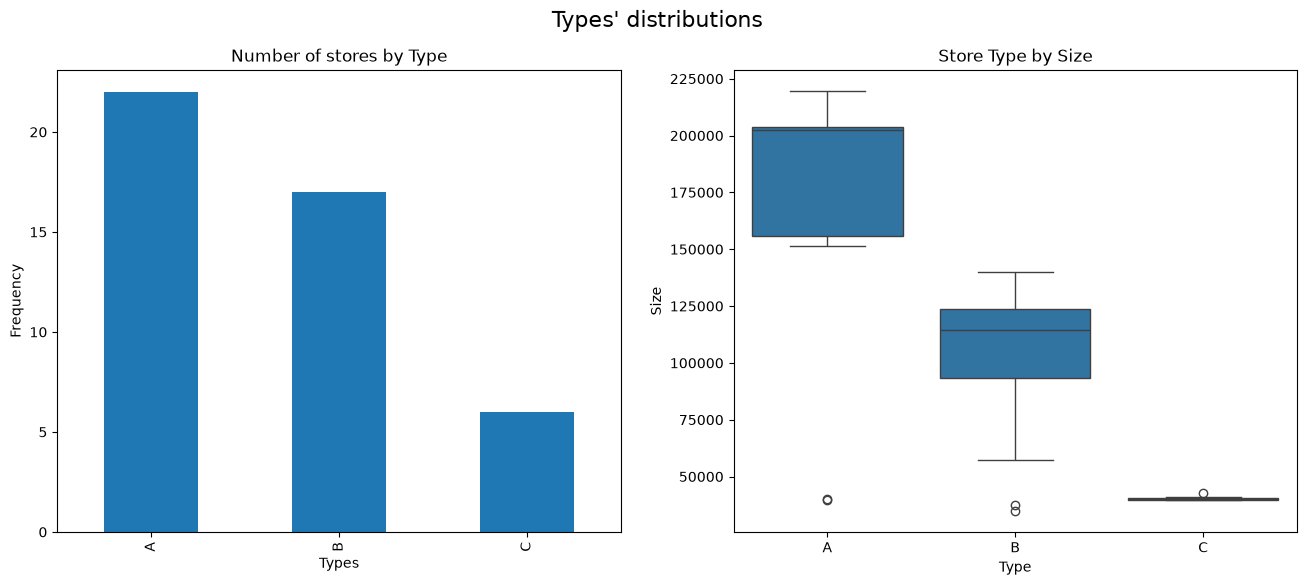

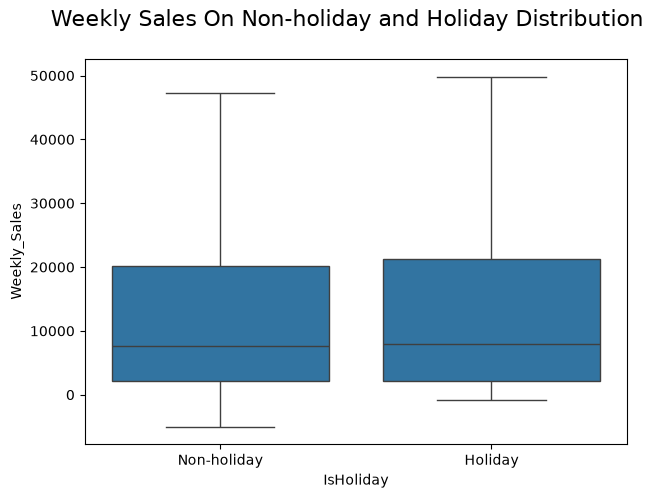

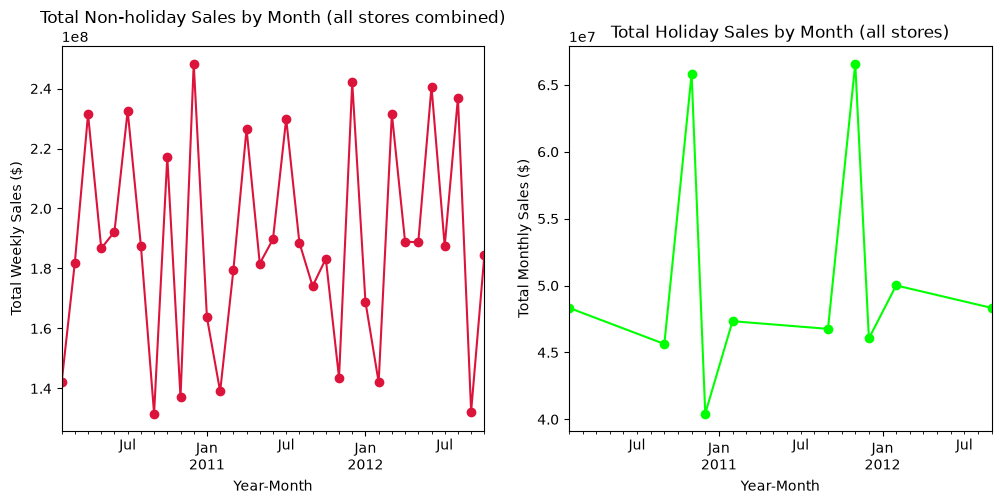

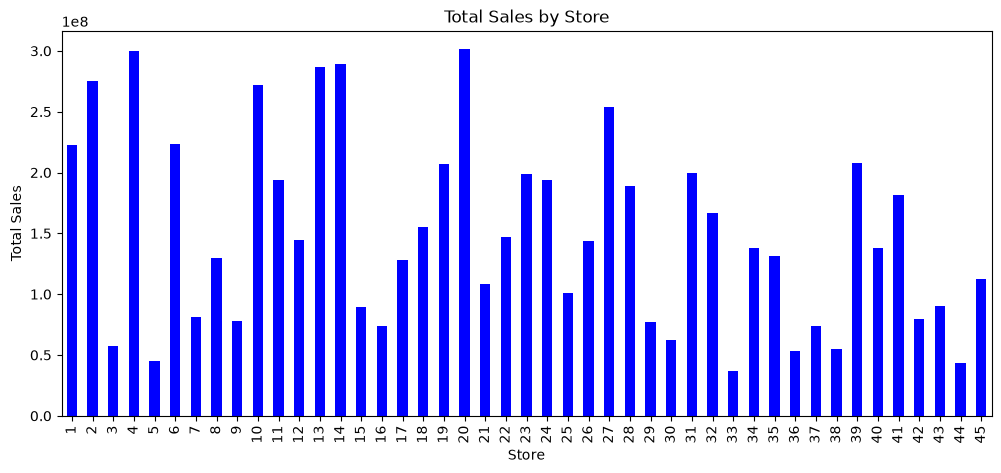

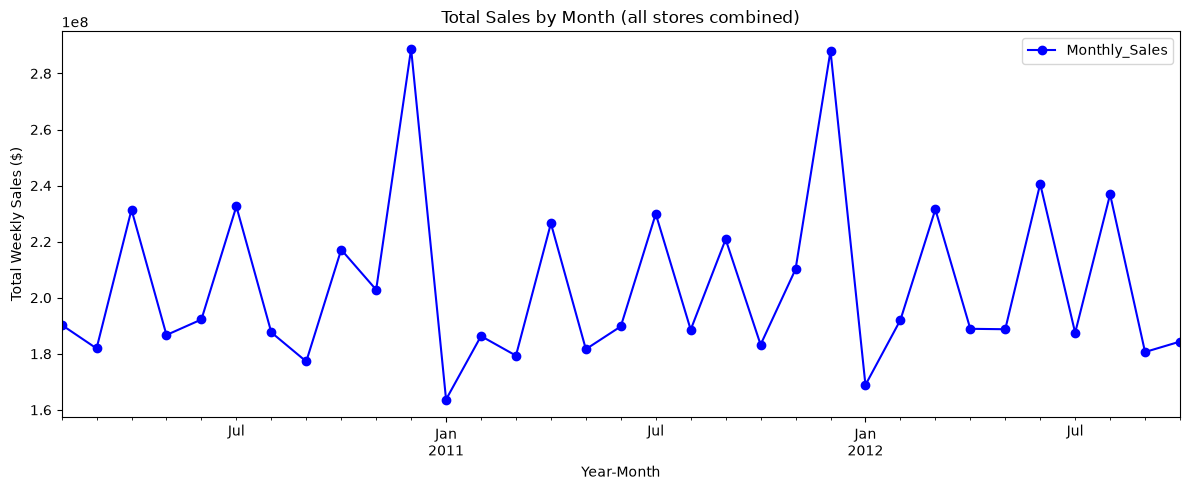

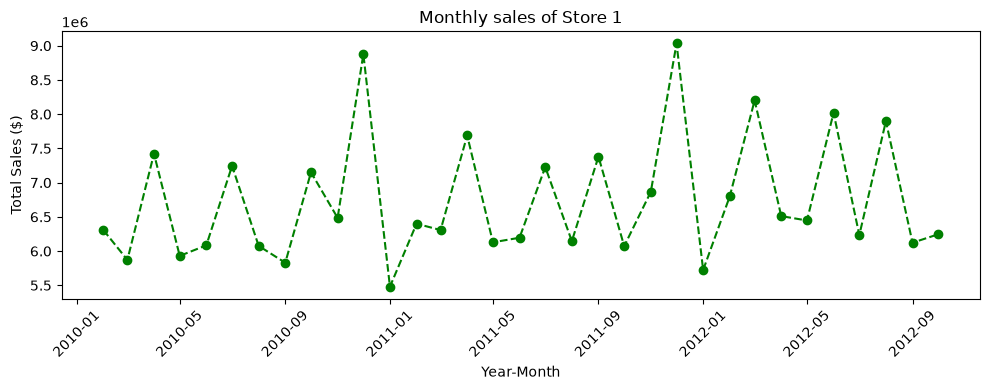

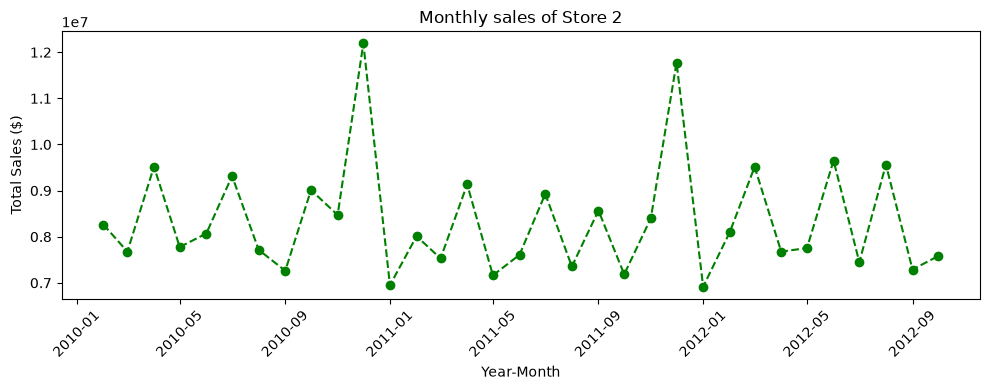

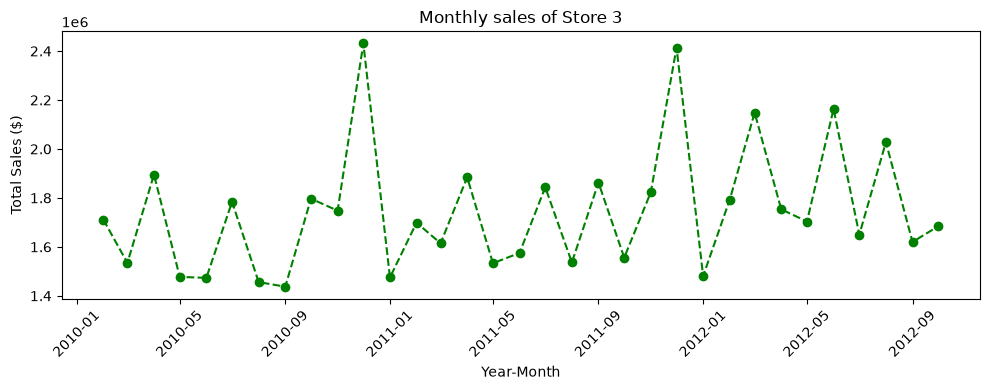

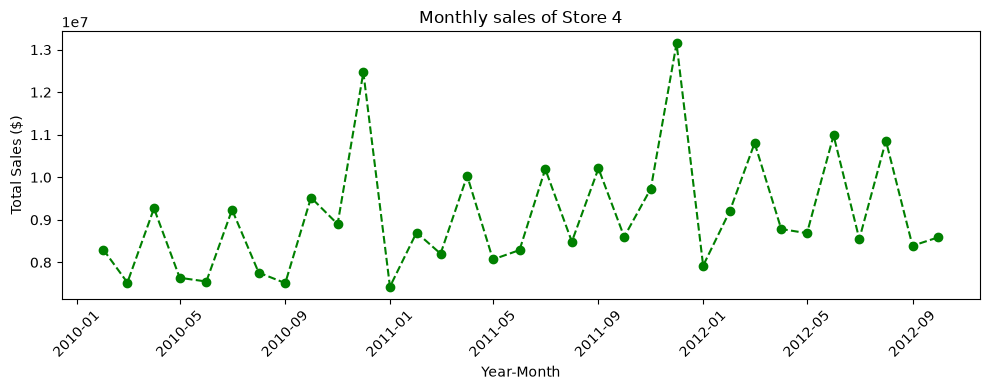

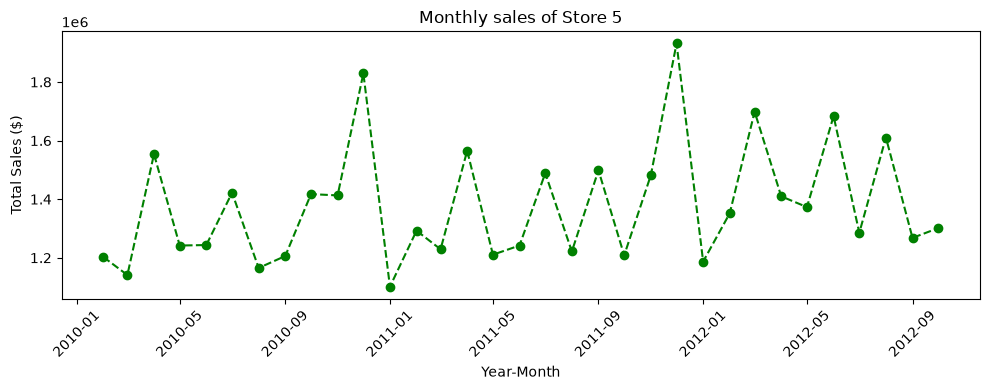

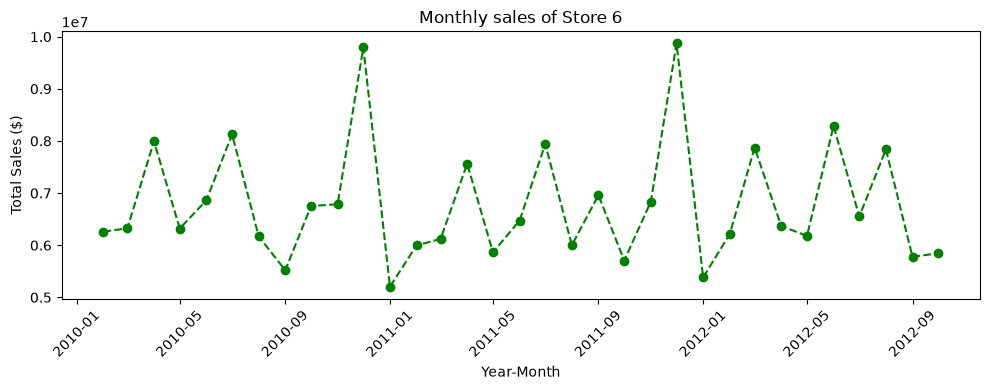

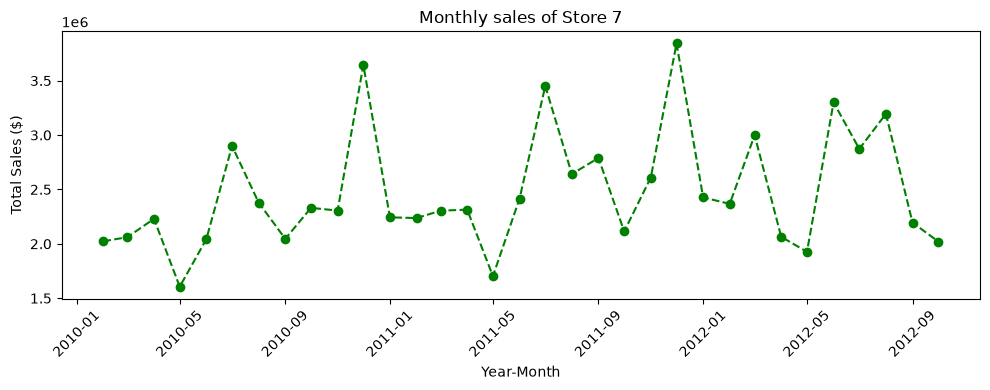

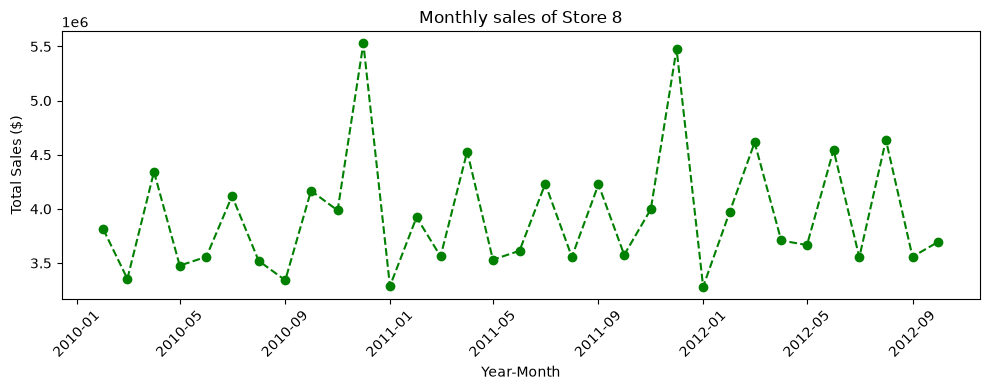

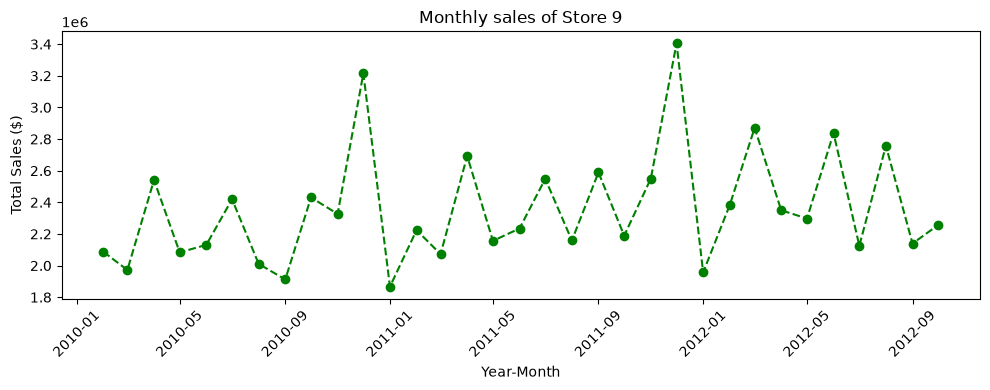

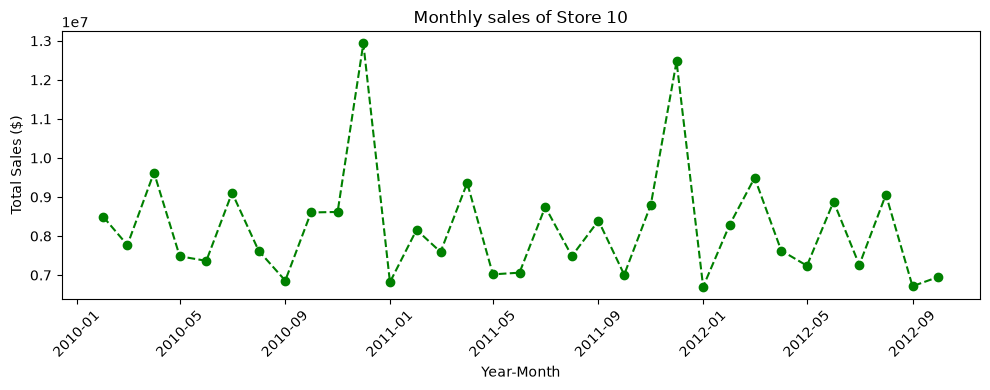

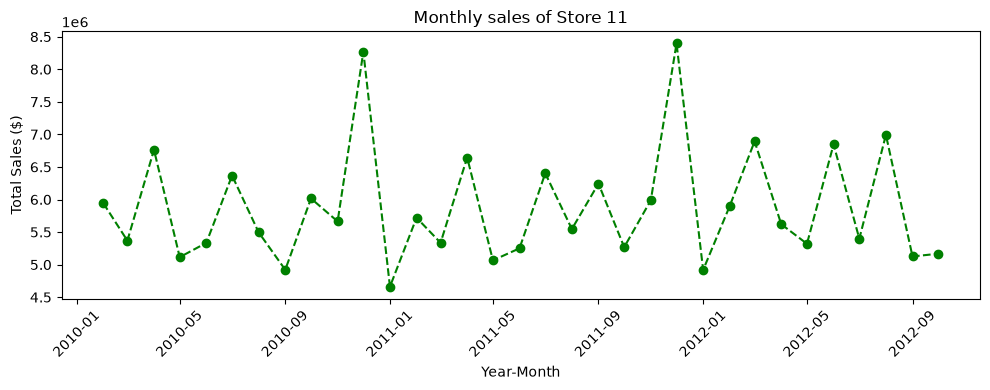

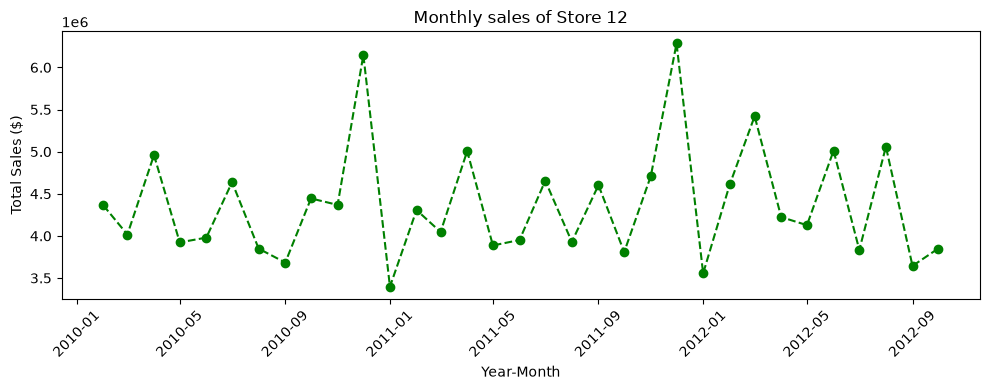

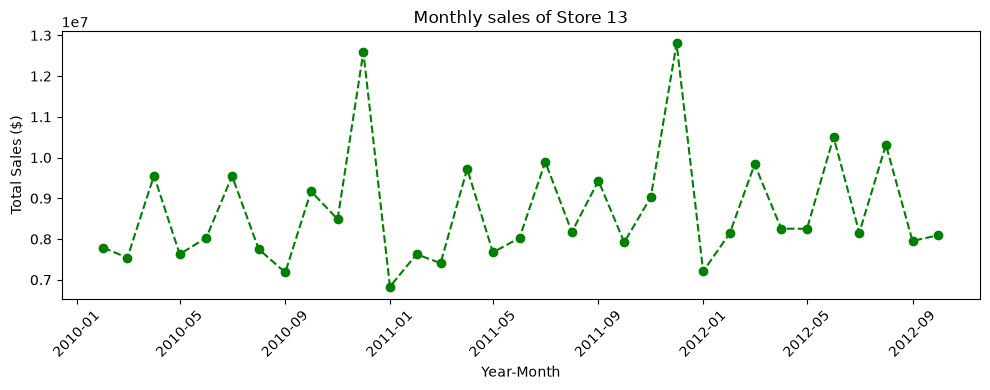

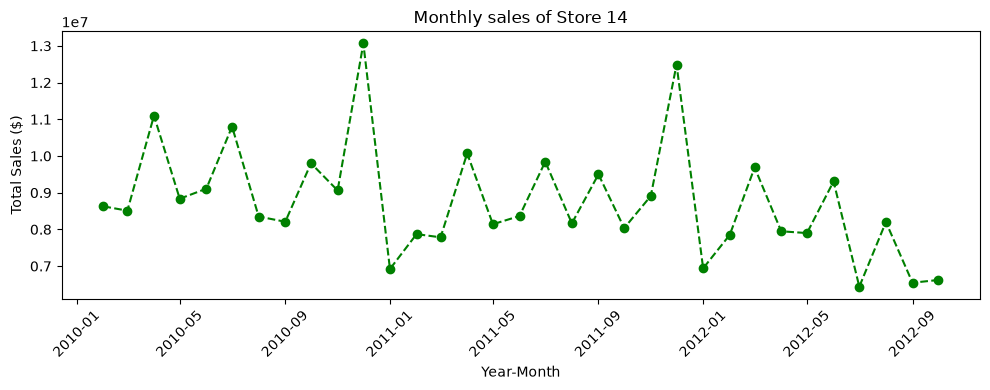

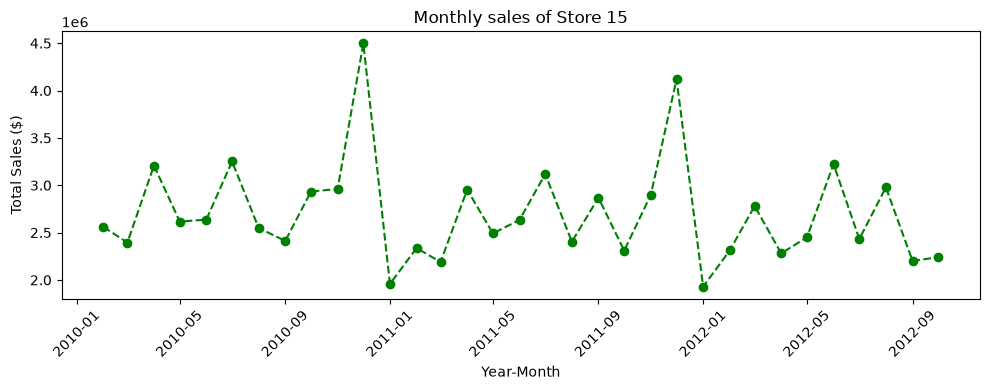

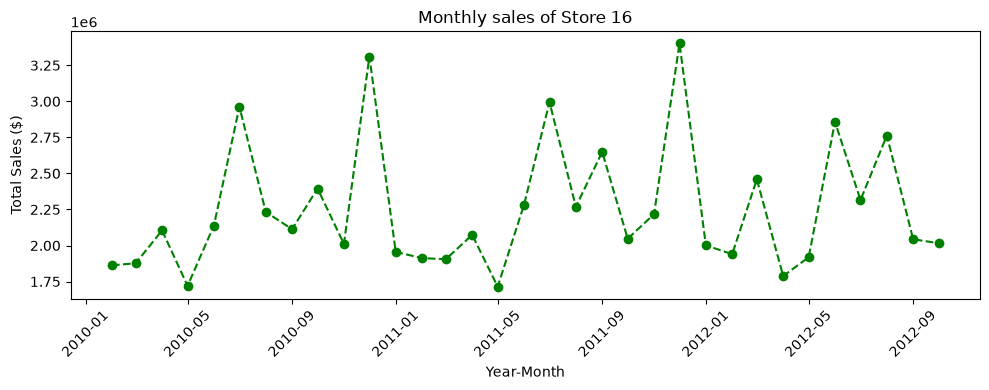

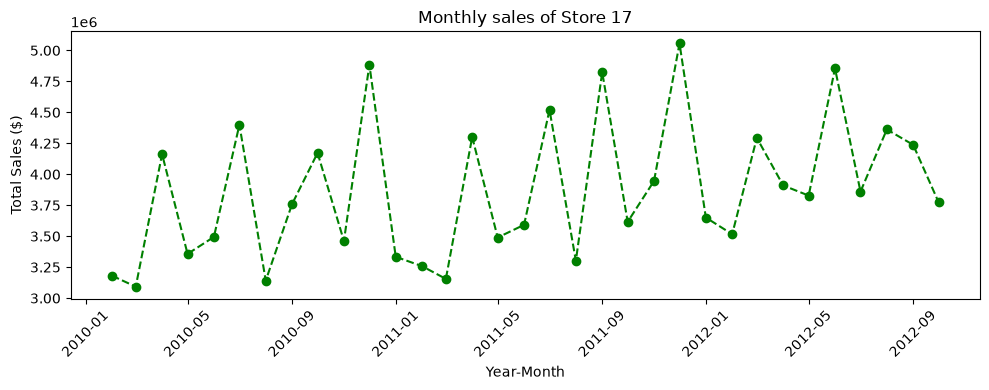

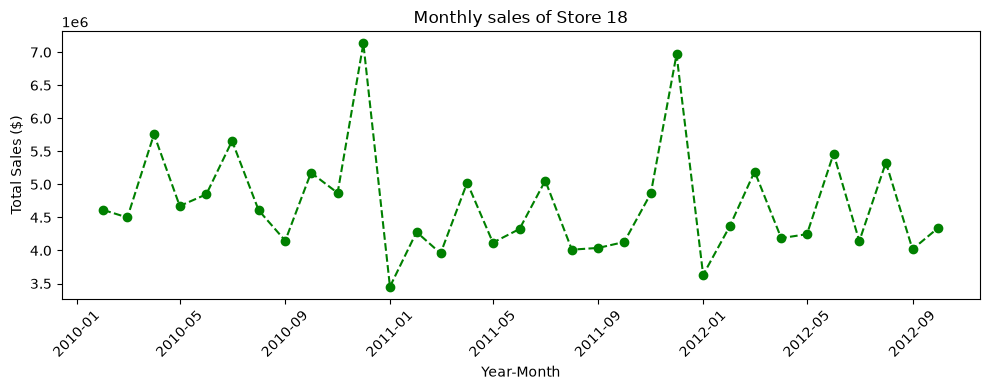

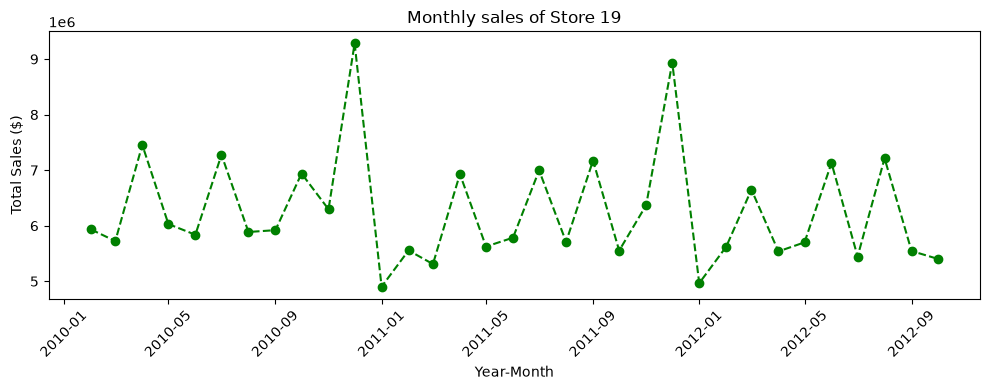

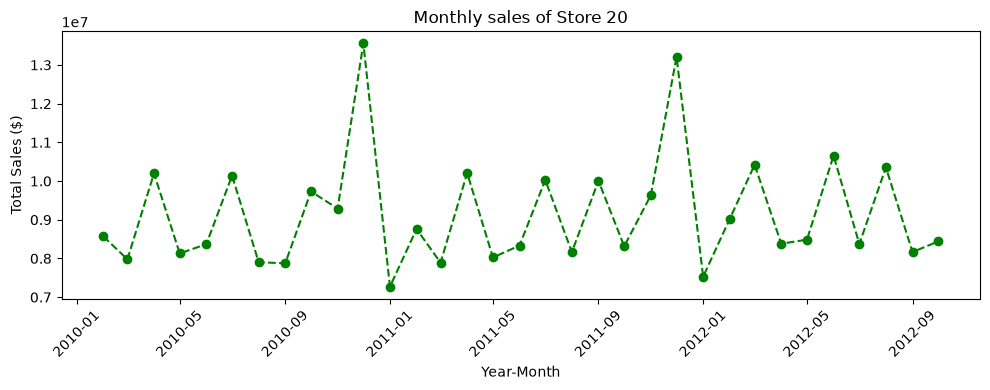

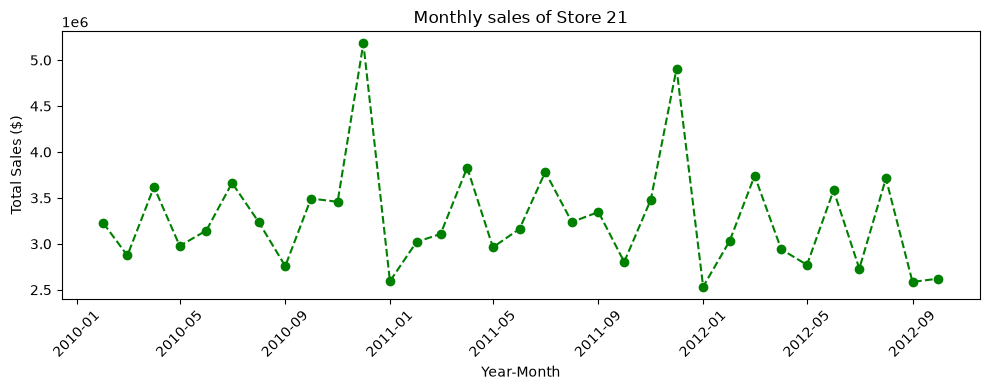

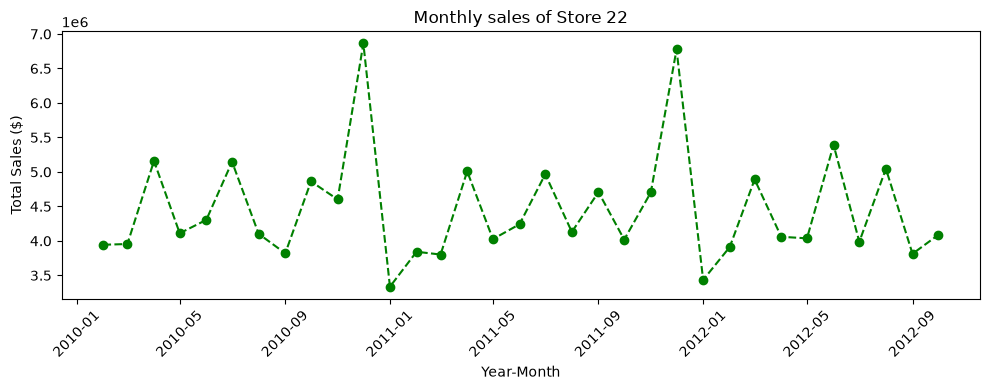

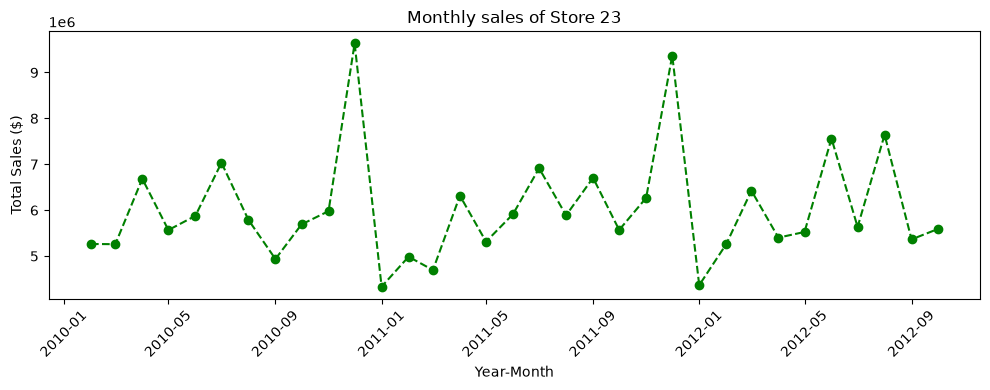

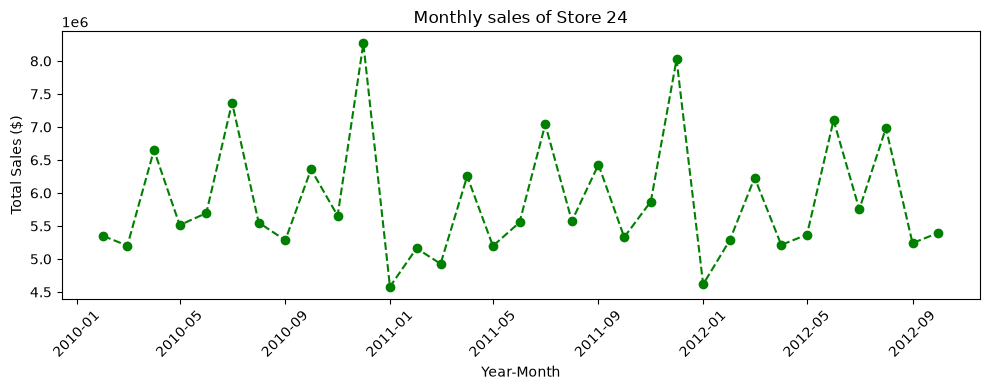

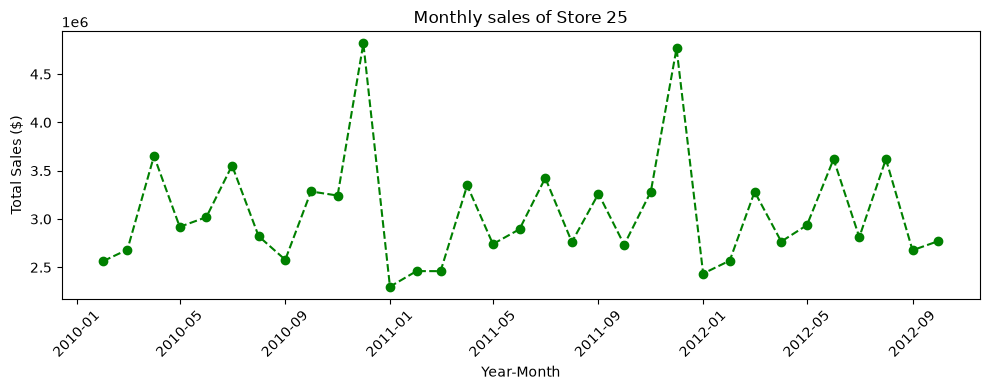

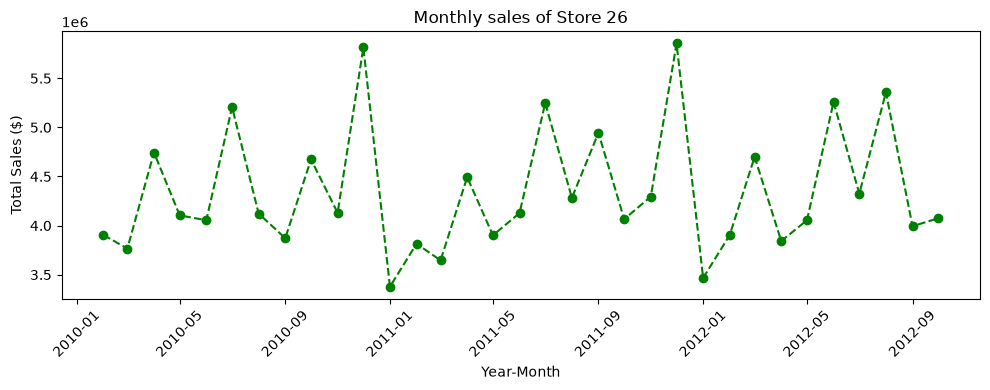

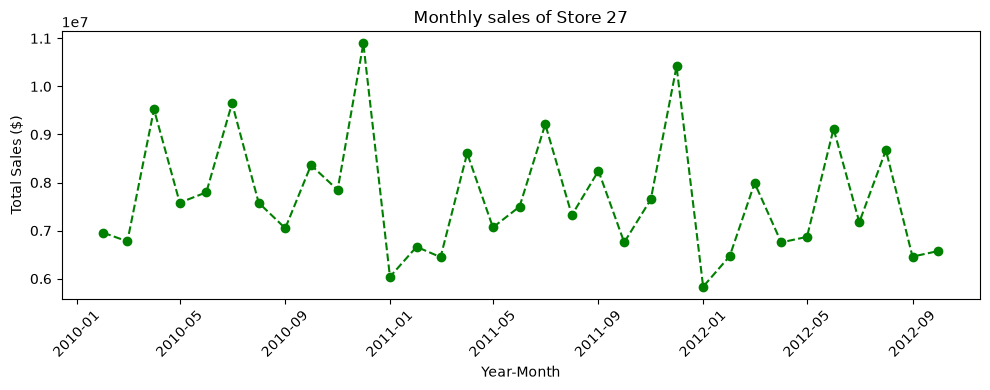

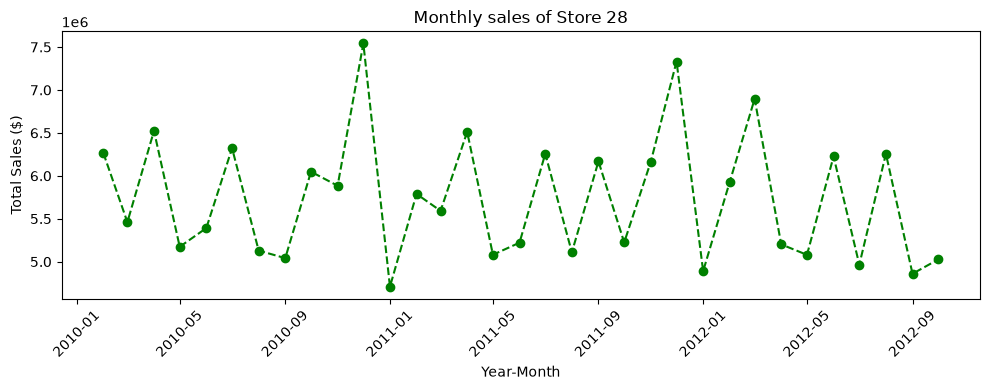

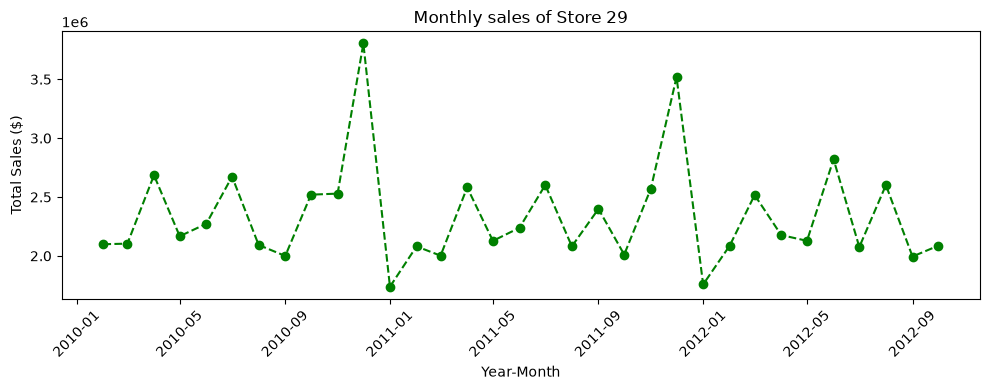

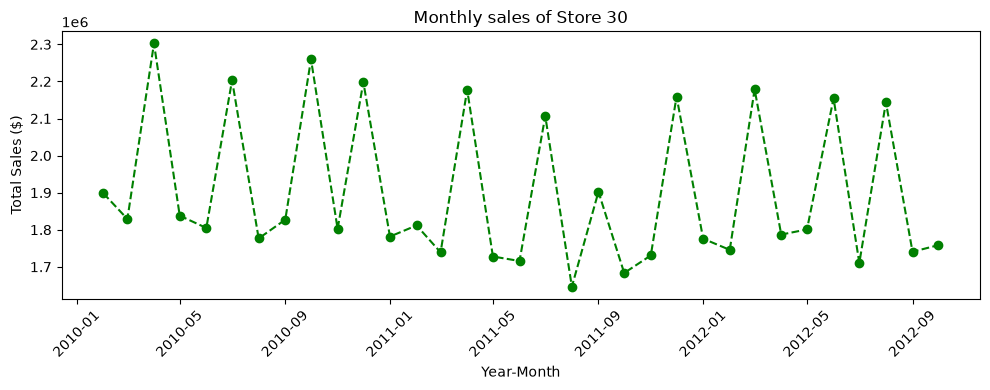

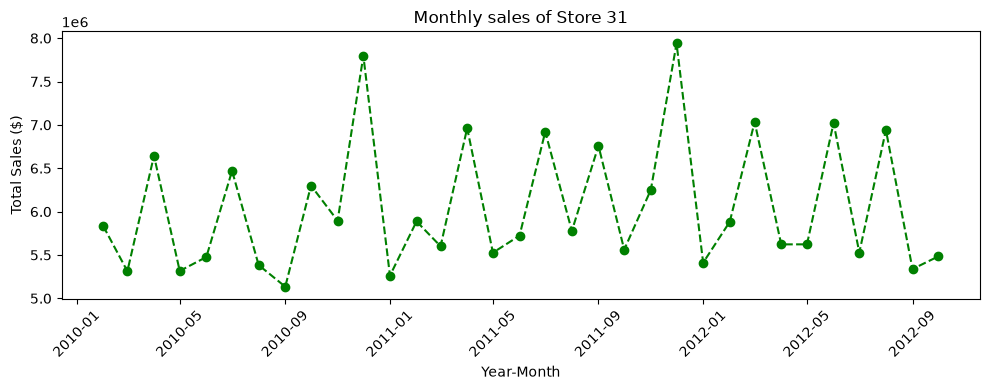

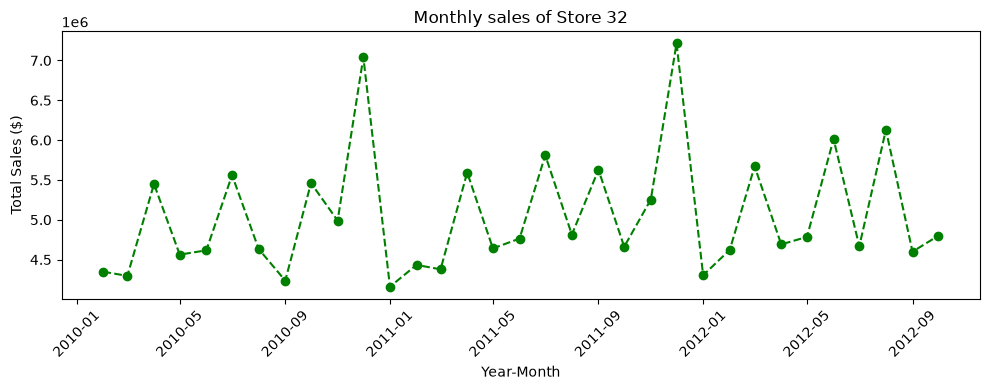

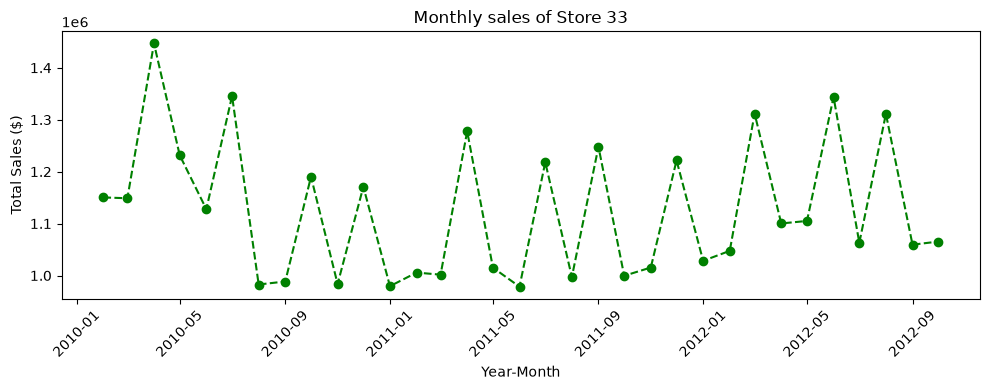

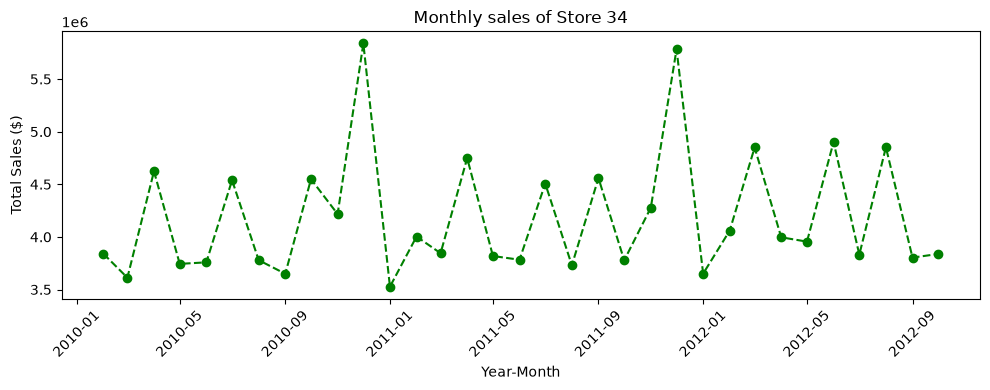

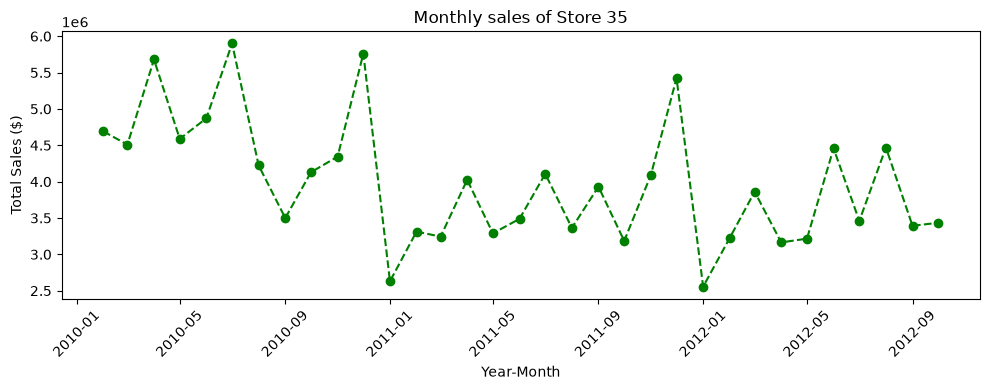

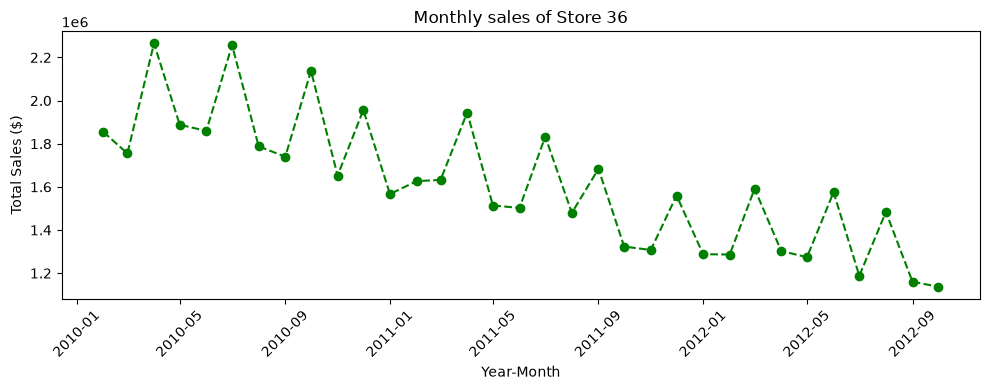

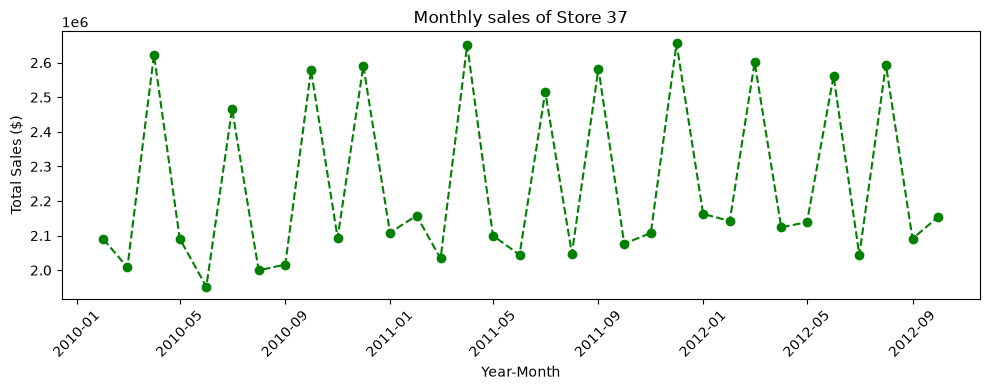

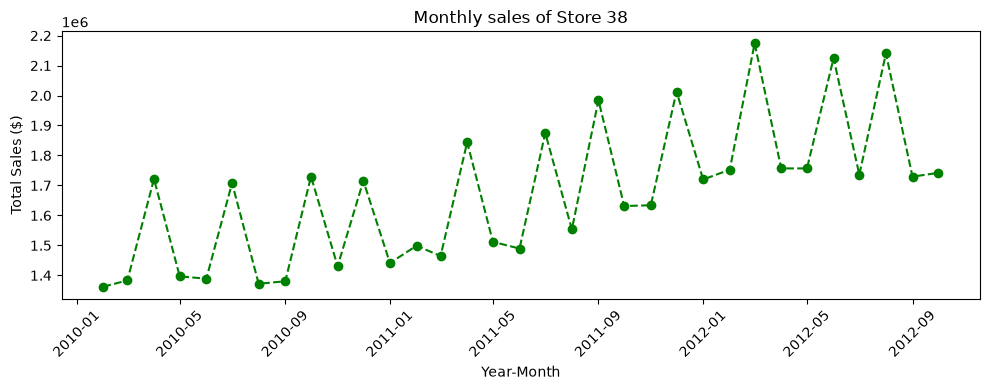

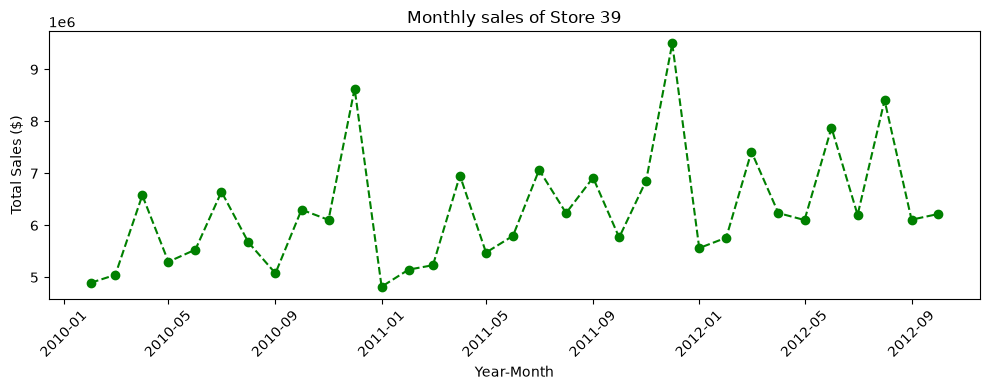

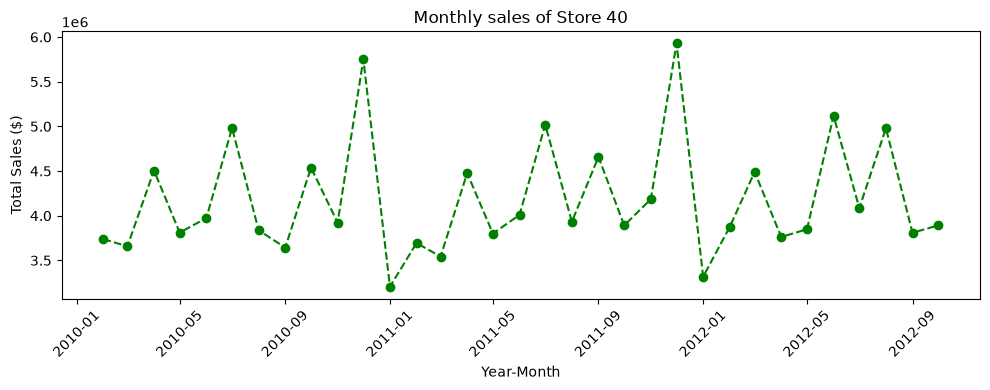

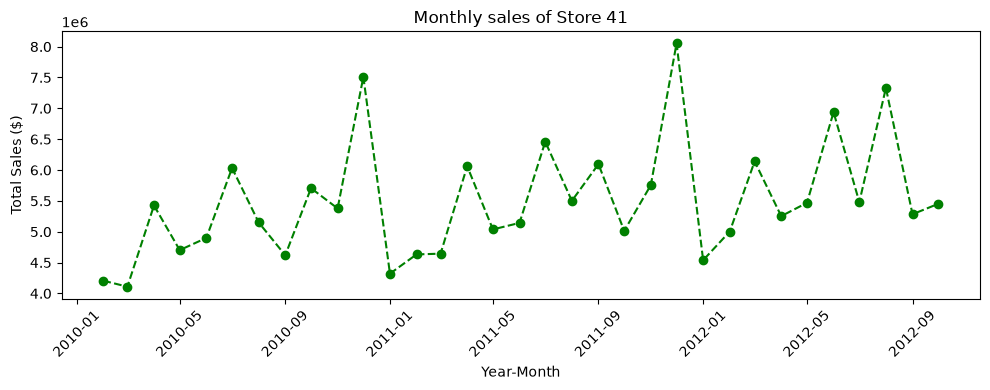

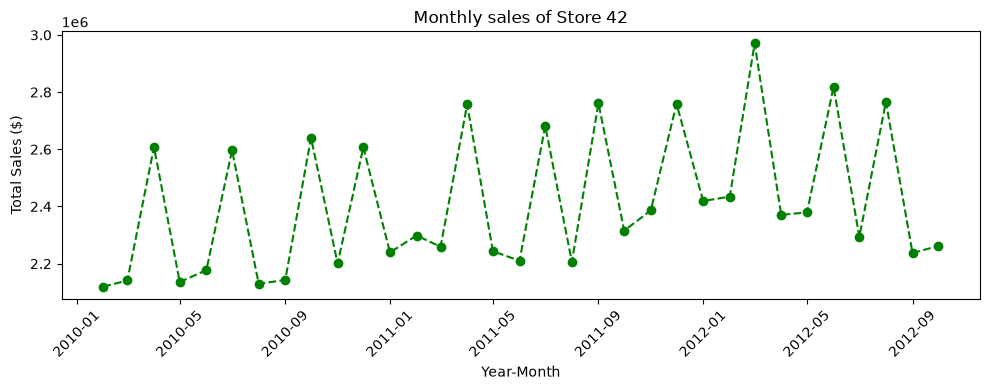

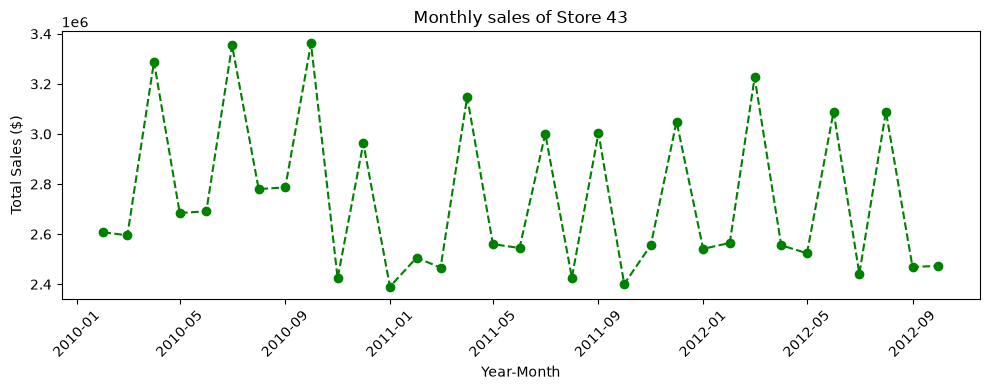

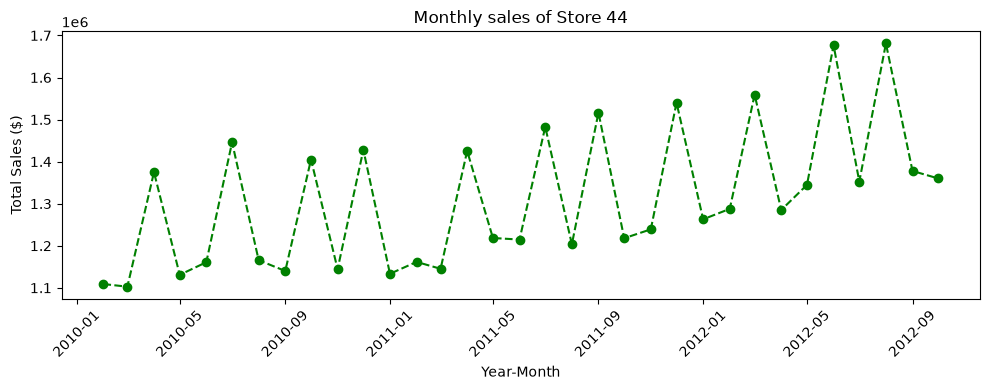

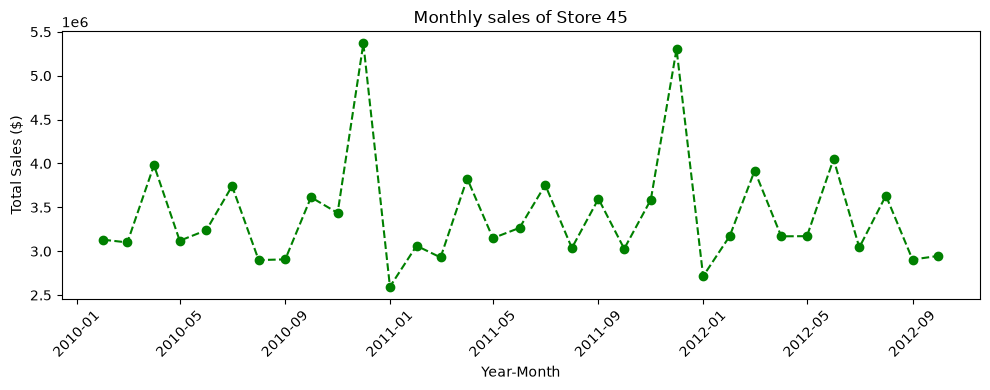

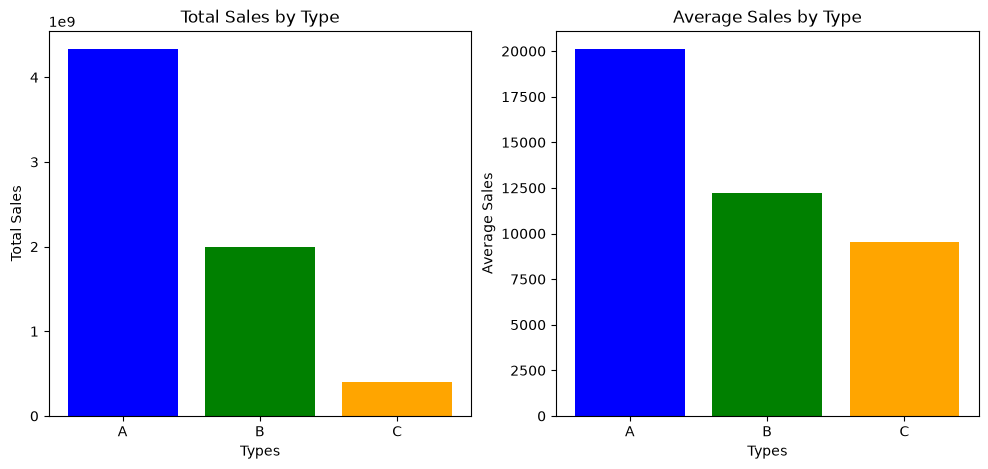

In [19]:
### Visualise the converted data from the task above and identify any trends, patterns, or anomalies.
### Hint: You can choose to aggregate data into daily, weekly, monthly, quarterly and yearly for visualization and analysis purposes. Check this chapter from otexts for more information on visualizing time-series data.
## Sizes vs Types
fig, ax = plt.subplots(1, 2, figsize=(16,6))
# Bar plot of Types vs Frequency:
store_df["Type"].value_counts().plot(kind="bar", ax=ax[0])
ax[0].set_title("Number of stores by Type")
ax[0].set_xlabel("Types")
ax[0].set_ylabel("Frequency")

# Scatter plot of store type vs size on the second axis
sns.boxplot(x="Type", y="Size", data=store_df)
ax[1].set_title("Store Type by Size")
ax[1].set_xlabel("Type")
ax[1].set_ylabel("Size")

plt.suptitle("Types' distributions", fontsize=16)
plt.show()

## Weekly Sales in Non-holiday vs Holiday Distribution
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=sales_df, x="IsHoliday", y="Weekly_Sales", showfliers=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Non-holiday", "Holiday"])
plt.suptitle("Weekly Sales On Non-holiday and Holiday Distribution", fontsize=16)
plt.show()


## Plot Weekly Sales in Non-holiday vs Holiday
sales_df["YearMonth"] = sales_df["Date"].dt.to_period("M")
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Non-holiday:
non_holiday = sales_df[sales_df["IsHoliday"] == 0]
monthly_sales_non_holiday = non_holiday.groupby("YearMonth")["Weekly_Sales"].sum()
monthly_sales_non_holiday.plot(kind="line", marker="o", ax=ax[0], color="crimson")
ax[0].set_title("Total Non-holiday Sales by Month (all stores combined)")
ax[0].set_xlabel("Year-Month")
ax[0].set_ylabel("Total Weekly Sales ($)")

# Holiday
holiday = sales_df[sales_df["IsHoliday"] == 1]
monthly_sales_holiday = holiday.groupby("YearMonth")["Weekly_Sales"].sum()
monthly_sales_holiday.plot(kind="line", marker="o", ax=ax[1], color="lime")
ax[1].set_title("Total Holiday Sales by Month (all stores)")
ax[1].set_xlabel("Year-Month")
ax[1].set_ylabel("Total Monthly Sales ($)")
plt.show()

## Sales vs Stores
# Total sales by store
sales_by_store_df = sales_df.groupby("Store")["Weekly_Sales"].sum()
fig, ax = plt.subplots(figsize=(12,5))
sales_by_store_df.plot(kind="bar", ax=ax, color="blue")
ax.set_xlabel("Store")
ax.set_ylabel("Total Sales")
ax.set_title("Total Sales by Store")
plt.show()

# Monthly sales all stores
monthly_sales_stores = sales_df.groupby(["Store", "YearMonth"])["Weekly_Sales"].sum().reset_index(name="Monthly_Sales")
monthly_sales = monthly_sales_stores.groupby("YearMonth").sum()
monthly_sales = monthly_sales.drop(columns="Store")
fig, ax = plt.subplots(figsize=(12, 5))
monthly_sales.plot(kind="line", marker="o", ax=ax, color="blue")
ax.set_title("Total Sales by Month (all stores combined)")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Total Weekly Sales ($)")
plt.tight_layout()
plt.show()

# Monthly sales of every store 
stores = monthly_sales_stores.groupby("Store")
for store, store_data in stores:
    plt.figure(figsize=(10,4))
    plt.plot(store_data["YearMonth"].dt.to_timestamp(), store_data["Monthly_Sales"], color='green', marker='o', linestyle='--')
    plt.title(f"Monthly sales of Store {store}")
    plt.xlabel("Year-Month")
    plt.ylabel("Total Sales ($)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Merge sales_df & stores_df: 
sales_stores_df = sales_df.merge(store_df, how="left", on="Store")
sales_by_types = sales_stores_df.groupby("Type")["Weekly_Sales"].agg(["sum", "mean"])

# Sales per type:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Total sales per type:
ax[0].bar(sales_by_types.index, sales_by_types["sum"], color=["blue", "green", "orange"])
ax[0].set_title("Total Sales by Type")
ax[0].set_xlabel("Types")
ax[0].set_ylabel("Total Sales")

# Average sales per type:
ax[1].bar(sales_by_types.index, sales_by_types["mean"], color=["blue", "green", "orange"])
ax[1].set_title("Average Sales by Type")
ax[1].set_xlabel("Types")
ax[1].set_ylabel("Average Sales")
plt.show()


## 4. Identify correlated variables

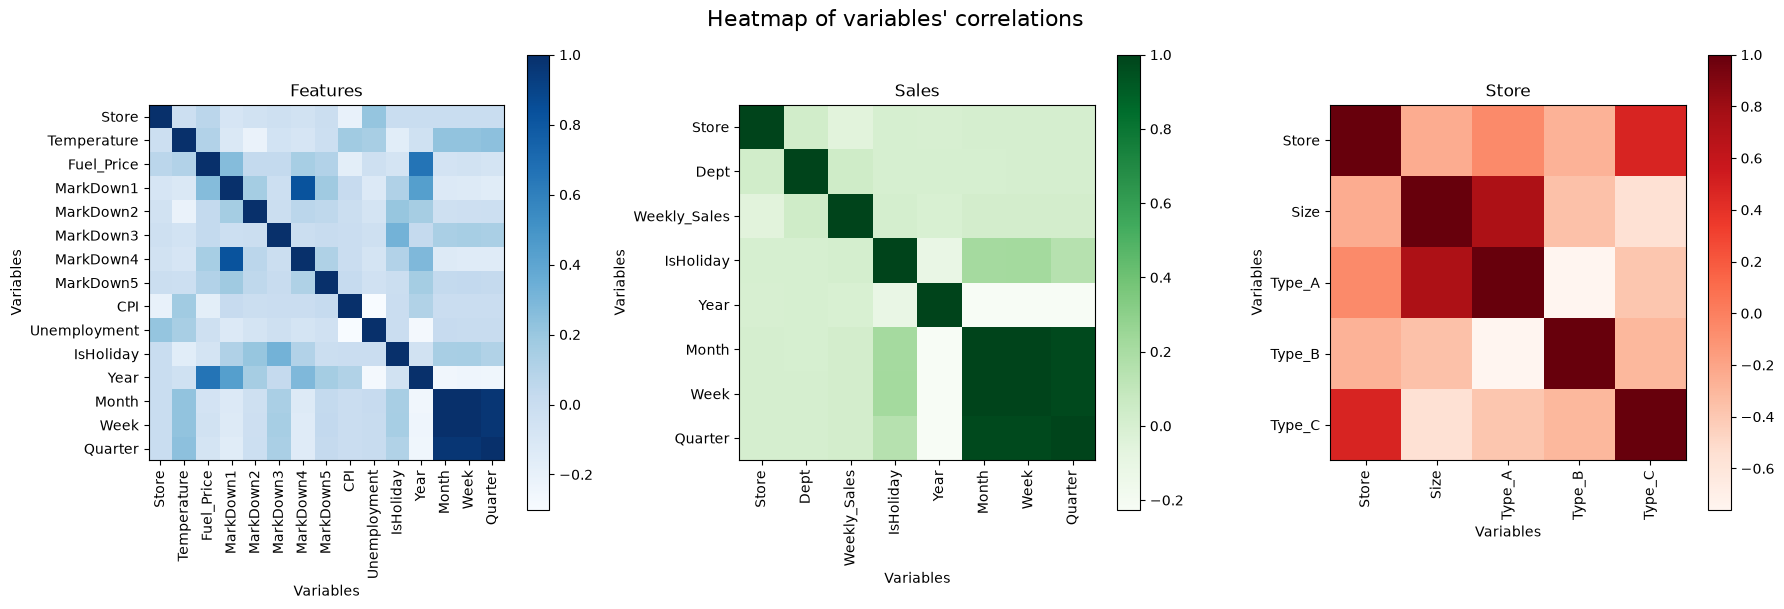

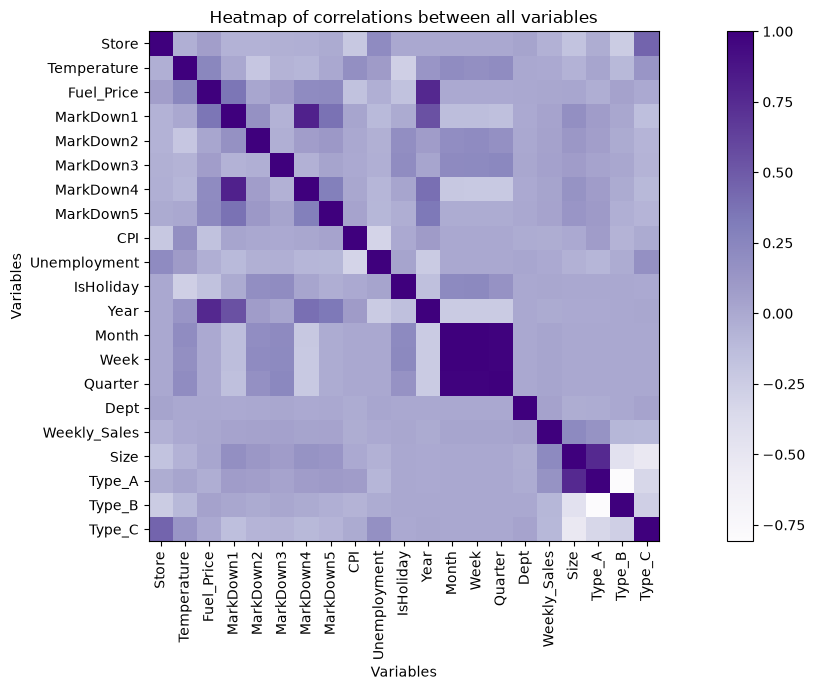

Weekly_Sales    1.000000
Size            0.219415
Type_A          0.149276
MarkDown3       0.048833
MarkDown2       0.041890
Dept            0.040606
MarkDown5       0.038572
MarkDown1       0.037093
MarkDown4       0.026266
Quarter         0.021566
Week            0.021049
Month           0.020720
IsHoliday       0.008285
Fuel_Price      0.006106
Temperature    -0.003341
Unemployment   -0.007305
Year           -0.010846
CPI            -0.030690
Store          -0.056003
Type_B         -0.091324
Type_C         -0.098233
Name: Weekly_Sales, dtype: float64
Index(['Store', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday', 'Year', 'Month', 'Dept', 'Weekly_Sales', 'Size'],
      dtype='str')


'\nREASONS:\n- Weekly_Sales variable is a response variable which is depended on other explanatory variables.\n\n* Drop Type_A, Type_B, Type_B (Type) => Keep Size\n- In heatmap of Store dataset, it shows that there is a strong association between Size and Type A since their \ncorrelation is ~0.73. This suggests potential multicollinearity, but we can keep both of them in the dataset and\nuse them for different aspects. \n    + For linear regression, Size is the continuous numerical variables which may be prefered to use alone with \nWeekly_Sales variable. Adding Type variables can lead to redundancy as they have similar information. Thus, we may\nneed to drop one-hot encoded Type variables in this case. \n    + For tree-based algorithms (Decision tree), we do not need to drop the variables as the algorithms is not very\naffected by multicollinearity\n\n* Drop Week, Quater => Keep Month\n- It shows that the correlations between Month, Week and Quater are close to 1 (~0.9) which suggests

In [18]:
###Find correlations between variables within each dataset to determine how each variable relates to the others.
## features_df
correlation_features_df = final_features_df.corr(numeric_only=True)
correlation_features_df

## sales_df
correlation_sales_df = final_sales_df.corr(numeric_only=True)
correlation_sales_df

## store_df
correlation_store_df = store_df_encoded.corr(numeric_only=True)
correlation_store_df

###Identify and highlight any apparent relationships between variables.
## Create a heatmap using matplotlib

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# correlation_features_df
image1 = ax[0].imshow(correlation_features_df, interpolation='nearest', cmap=plt.cm.Blues)
features_classes = final_features_df.columns
features_tick_marks = np.arange(len(features_classes))
ax[0].set_title("Features")
ax[0].set_xticks(features_tick_marks)
ax[0].set_xticklabels(features_classes, rotation=90)
ax[0].set_yticks(features_tick_marks)
ax[0].set_yticklabels(features_classes)
ax[0].set_xlabel("Variables")
ax[0].set_ylabel("Variables")
fig.colorbar(image1, ax=ax[0])

# correlation_sales_df
image2 = ax[1].imshow(correlation_sales_df, interpolation='nearest', cmap=plt.cm.Greens)
sales_classes = final_sales_df.columns
sales_tick_marks = np.arange(len(sales_classes))
ax[1].set_title("Sales")
ax[1].set_xticks(sales_tick_marks)
ax[1].set_xticklabels(sales_classes, rotation=90)
ax[1].set_yticks(sales_tick_marks)
ax[1].set_yticklabels(sales_classes)
ax[1].set_xlabel("Variables")
ax[1].set_ylabel("Variables")
fig.colorbar(image2, ax=ax[1])

# correlation_store_df
image3 = ax[2].imshow(correlation_store_df, interpolation='nearest', cmap=plt.cm.Reds,)
store_classes = store_df_encoded.columns
store_tick_marks = np.arange(len(store_classes))
ax[2].set_title("Store")
ax[2].set_xticks(store_tick_marks)
ax[2].set_xticklabels(store_classes, rotation=90)
ax[2].set_yticks(store_tick_marks)
ax[2].set_yticklabels(store_classes)
ax[2].set_xlabel("Variables")
ax[2].set_ylabel("Variables")
fig.colorbar(image3, ax=ax[2])

plt.suptitle("Heatmap of variables' correlations", fontsize=16)
plt.tight_layout()
plt.show()

# Merge 3 datasets
merge_df = final_features_df.merge(final_sales_df, how="left", on=['Store', 'IsHoliday', 'Year', 'Month', 'Week', 'Quarter'])
final_meger_df = merge_df.merge(store_df_encoded, how="left", on="Store")
correlation_final_meger_df = final_meger_df.corr(numeric_only=True)


# Heatmap of correlations between all variables
plt.figure(figsize=(14,7))
plt.imshow(correlation_final_meger_df, interpolation='nearest', cmap=plt.cm.Purples) 
plt.title('Heatmap of correlations between all variables') 
plt.colorbar() 
merge_classes = final_meger_df.columns 
merge_tick_marks = np.arange(len(merge_classes)) 
plt.xticks(merge_tick_marks, merge_classes, rotation=90) 
plt.yticks(merge_tick_marks, merge_classes) 
plt.ylabel('Variables') 
plt.xlabel('Variables') 
plt.tight_layout() 
plt.show()

## Correlations of variables with Weekly_Sales:
Weekly_Sales_corr = correlation_final_meger_df["Weekly_Sales"]
print(Weekly_Sales_corr.sort_values(ascending=False))

###Drop/keep features that may depend on others while stating your reasoning.
final_meger_df = final_meger_df.drop(columns=["Type_A", "Type_B", "Type_C", 'Week', 'Quarter'])
print(final_meger_df.columns)
"""
REASONS:
- Weekly_Sales variable is a response variable which is depended on other explanatory variables.

* Drop Type_A, Type_B, Type_B (Type) => Keep Size
- In heatmap of Store dataset, it shows that there is a strong association between Size and Type A since their 
correlation is ~0.73. This suggests potential multicollinearity, but we can keep both of them in the dataset and
use them for different aspects. 
    + For linear regression, Size is the continuous numerical variables which may be prefered to use alone with 
Weekly_Sales variable. Adding Type variables can lead to redundancy as they have similar information. Thus, we may
need to drop one-hot encoded Type variables in this case. 
    + For tree-based algorithms (Decision tree), we do not need to drop the variables as the algorithms is not very
affected by multicollinearity

* Drop Week, Quater => Keep Month
- It shows that the correlations between Month, Week and Quater are close to 1 (~0.9) which suggests multicollinearity. 
Additionally, these variables are created by Date variable, so they are related. We can only keep one variable out of
them. Choosing variable is depended on the purpose of using these data. In this case, using variable Month to extract 
data is better than others as it is easier to extract, analyse and compare the sale between months of different years.

* Other variables:
- Although other variables have weak correlations with Weekly_Sales, they still have an influence on the Weekly_Sales. 
For example:
+ IsHoliday: In the visualisation of boxplot of variable IsHoliday and Weekly_Sales, it shows that the weeks having
holiday contribute slightly more sales than non-holiday weeks. 
+ Markdown1-5: These variables affects directly to the Weekly_Sales as they may have different promotions which can
change the selling price of products in those weeks. 
+ Temperature, Fuel_Price, CPI, Unemployment: These variables can be considered as external factors which can change
the customers behaviours, delivery fees, inflation, consumer spending respectively. These mnay impact the selling price
of the products in periods of time.
Therefore, keeping the variables is very useful for a predictive model.
"""

## 5. Summary

The steps I've taken to perform EDA and preprocessing:
- Chose W store datasets and loaded features.csv, sales.csv, and stores.csv files
- Checked number of rows and columns of datasets (.shape)
- Overview first 10 instances of datasets. (.head(10))
- Displayed key statistical measures (mean and standard deviation) (.describe())
- Visualised (histogram, boxplot, bar, line) numerical (Temperature, Fuel_Price, CPI, Unemployment, Markdowns, Weekly_Sales, Sizes) and categorical variables (Type, Store)
- Checked types of variables and converted them to numerical values
- Checked missing values of columns in datasets (.isnull().sum(),  .isnull().any(axis=1)) and filled missing values of markdowns, and CPI and Unemployment by 0 and median respectively
- Removed outliers (negative sales, unusual and extremely high weekly sales)
- Standardise values’ variables by their means and standard deviation (StandardScaler())
- Balanced number of values in IsHoliday column
- Dropped insignificant column (Date, YearMonth)
- Identifed correlations between variables and them with weekly sales (response variable) and dropped variables that may cause potential multicollinearity


Interesting findings:
- Weekly_Sales is very strongly right-skewed and contains many outliers which are extremely high values. The visualisation of monthly sales of most stores showing a clear pattern that they have peak seasons in a certain month (December). Weekly_Sales also contains several negative sales which suggest the amount of product return exceed purchases.
- More than half of markdown columns' values are missing which suggest there is no promotions run in that week. Thus, filling missing values by 0 is appropriate.
- There are serveral CPI and Unemployment values are missing which suggest the values may not be collected yet as they are barely be nothing or exactly 0. Thus, filling missing values by their median is appropriate as their values are not distributed evenly.